In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv("../data/raw/ObesityDataSet.csv")
df = data.copy()

In [3]:
# Creamos la columna IMC (Peso / Altura al cuadrado)
df['imc'] = df['Weight'] / (df['Height'] ** 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [5]:
df.shape

(2111, 18)

In [6]:
df = df.drop_duplicates()

In [7]:
df.shape

(2087, 18)

In [8]:
# Diccionario para renombrar las columnas a snake_case
nuevos_nombres = {
    'Age': 'age',
    'Height': 'height',
    'Weight': 'weight',
    'FCVC': 'fcvc',
    'NCP': 'ncp',
    'CH2O': 'ch2o',
    'FAF': 'faf',
    'TUE': 'tue',
    'Gender': 'gender',
    'family_history_with_overweight': 'family_history',
    'FAVC': 'favc',
    'SMOKE': 'smoke',
    'SCC': 'scc',
    'CAEC': 'caec',
    'CALC': 'calc',
    'MTRANS': 'mtrans',
    'NObeyesdad': 'nobeyesdad',
    'imc' : 'imc'
}

df = df.rename(columns=nuevos_nombres)

In [9]:
df.head(10)

,gender,age,height,weight,family_history,favc,fcvc,ncp,caec,smoke,ch2o,scc,faf,tue,calc,mtrans,nobeyesdad,imc
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I,26.851852
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight,20.195092
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight,24.444444
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,19.705532
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight,20.199470
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight,22.985398


In [10]:
X= df.drop('nobeyesdad', axis=1)
y= df['nobeyesdad']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
# Creamos una carpeta para datos procesados si no existe
processed_data_path = '../data/processed/'
if not os.path.exists(processed_data_path):
    os.makedirs(processed_data_path)

# Guardamos X_test e y_test
X_test.to_csv(os.path.join(processed_data_path, 'X_test_g.csv'), index=False)
y_test.to_csv(os.path.join(processed_data_path, 'y_test_g.csv'), index=False)

print(" Datos de prueba guardados en data/processed/")

 Datos de prueba guardados en data/processed/


Preparamos el codigo para nuestro pipeline

In [13]:
# 1. Definimos los grupos de columnas
cols_num = ['age', 'height', 'weight', 'fcvc', 'ncp', 'ch2o', 'faf', 'tue', 'imc']
cols_binarias = ['gender', 'family_history', 'favc', 'smoke', 'scc']
cols_ordinales = ['caec', 'calc']
cols_nominales = ['mtrans']

# 2. Definimos el orden para las ordinales
categorias_orden = ['no', 'Sometimes', 'Frequently', 'Always']

# El Encoder necesita una lista por cada columna ordinal
lista_orden = [categorias_orden, categorias_orden]

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Definimos el transformador
preprocessor = ColumnTransformer(
    transformers=[
        # 1. Escalar numéricas
        ('num', StandardScaler(), cols_num),
        
        # 2. Codificar ordinales y binarias (usamos el orden que elegiste)
        ('ord', OrdinalEncoder(categories=[categorias_orden, categorias_orden]), cols_ordinales),
        
        # 3. Binarias simples (el encoder les asignará 0 y 1 automáticamente)
        ('bin', OrdinalEncoder(), cols_binarias),
        
        # 4. Nominal (crea columnas nuevas)
        ('nom', OneHotEncoder(handle_unknown='ignore'), cols_nominales)
    ]
)

Trasnformamos el target en una columna binaraia para poder predecir el nivel de obesidad

In [15]:
from sklearn.preprocessing import LabelEncoder

# 1. Creamos el objeto
le = LabelEncoder()

# 2. Ajustamos y transformamos la y (nuestro target)
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

ENTRENAMOS CON XGBOOST

In [16]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Creamos el Pipeline final
# El preprocessor es el que definimos antes con los escaladores y encoders
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'))
])

In [17]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Definimos el diccionario de parámetros
# Nota: Usamos 'classifier__' porque es el nombre que le dimos al paso en el Pipeline
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__subsample': [0.8] # Ayuda a prevenir overfitting
}

# Configuramos la validación cruzada (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Creamos el buscador
grid_search = GridSearchCV(
    estimator=model_pipeline,#mi modelo con xgboost
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1, # Usa todos los núcleos de tu procesador
    verbose=1
)
#entrenamos el modelo
grid_search.fit(X_train, y_train_encoded)


print("Los mejores parámetros son:", grid_search.best_params_)

# Imprimir la precisión media obtenida durante la validación cruzada
print("Precisión (Accuracy) en validación:", grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\gemit\Desktop\factoria-ia\PROYECTOS\p7_g1_multiclase\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:57:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Los mejores parámetros son: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
Precisión (Accuracy) en validación: 0.9844167520814228


In [18]:
# Predicciones sobre el conjunto de entrenamiento
y_train_pred = grid_search.predict(X_train)
# Predicciones sobre el conjunto de prueba (el examen real)
y_test_pred = grid_search.predict(X_test)

In [19]:
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Reporte de Clasificación (para comparar Train vs Test)
print("--- REPORTE DE ENTRENAMIENTO ---")
print(classification_report(y_train_encoded, y_train_pred))

print("--- REPORTE DE PRUEBA (TEST) ---")
print(classification_report(y_test_encoded, y_test_pred))

# 2. Preparación para la Curva ROC
# Necesitamos las probabilidades, no solo la predicción final
y_score = grid_search.predict_proba(X_test)

# Binarizamos la 'y' para poder calcular ROC por cada clase
y_test_bin = label_binarize(y_test_encoded, classes=[0, 1, 2, 3, 4, 5, 6])
n_classes = y_test_bin.shape[1]



--- REPORTE DE ENTRENAMIENTO ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       214
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       281
           3       1.00      1.00      1.00       237
           4       1.00      1.00      1.00       259
           5       1.00      1.00      1.00       221
           6       1.00      1.00      1.00       232

    accuracy                           1.00      1669
   macro avg       1.00      1.00      1.00      1669
weighted avg       1.00      1.00      1.00      1669

--- REPORTE DE PRUEBA (TEST) ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        53
           1       0.98      1.00      0.99        57
           2       1.00      0.99      0.99        70
           3       0.97      1.00      0.98        60
           4       1.00      0.98      0.99        65
           5

# CALCULAMOS EL  OVERFITTING

In [20]:
from sklearn.metrics import accuracy_score

# 1. Calculamos las precisiones exactas
train_acc = accuracy_score(y_train_encoded, y_train_pred)
test_acc = accuracy_score(y_test_encoded, y_test_pred)

# 2. Calculamos la diferencia
diferencia = (train_acc - test_acc) * 100

# 3. Imprimimos el resultado
print(f"Precisión en Entrenamiento: {train_acc:.4f}")
print(f"Precisión en Prueba (Test): {test_acc:.4f}")
print(f"Diferencia: {diferencia:.2f}%")


Precisión en Entrenamiento: 1.0000
Precisión en Prueba (Test): 0.9856
Diferencia: 1.44%


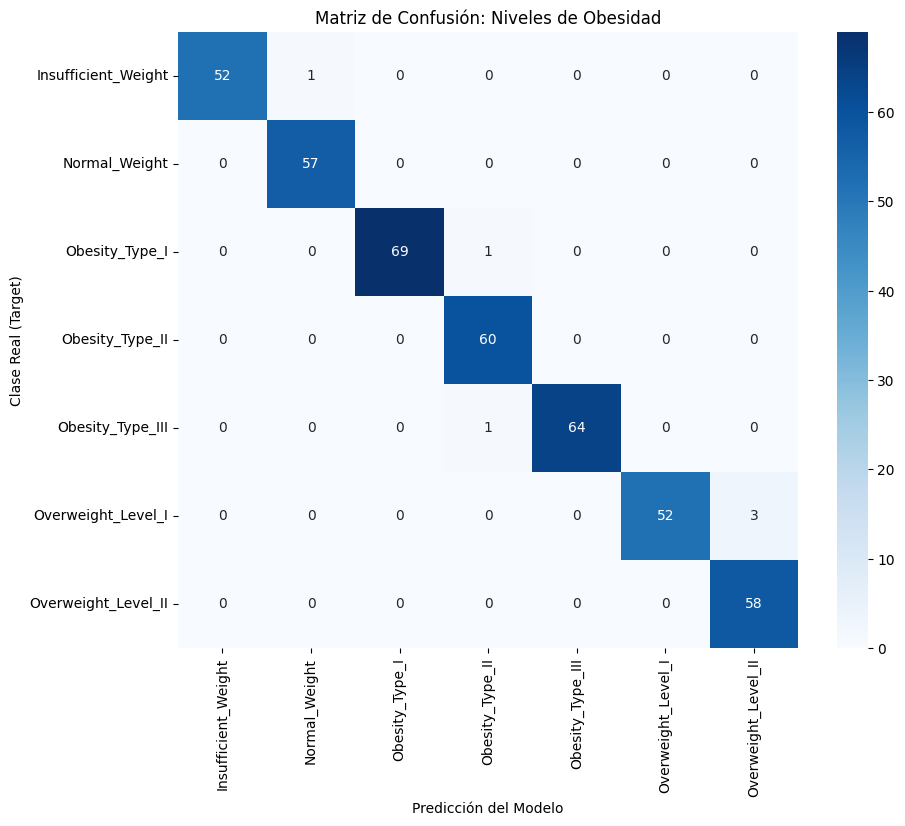

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calculamos la matriz con los datos de prueba
cm = confusion_matrix(y_test_encoded, y_test_pred)

# 2. Obtenemos los nombres de las categorías en orden (0, 1, 2...)
# Usamos el label encoder que guardamos antes
nombres_clases = le.classes_

# 3. Graficamos
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, 
            yticklabels=nombres_clases)

plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real (Target)')
plt.title('Matriz de Confusión: Niveles de Obesidad')
plt.show()

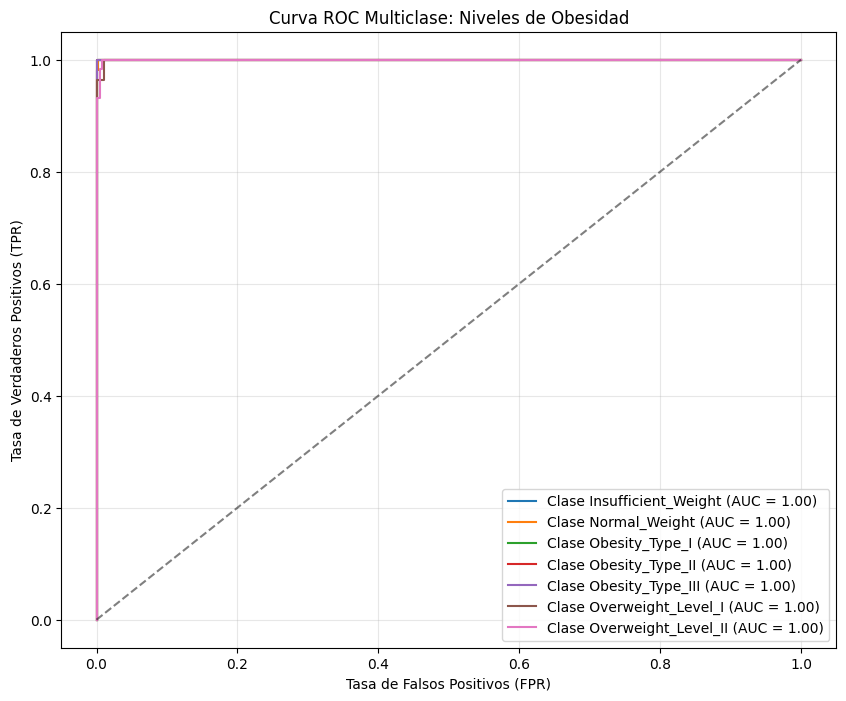

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Calculamos las probabilidades (necesarias para ROC)
y_probs = grid_search.predict_proba(X_test)

# 2. Configuramos el gráfico
plt.figure(figsize=(10, 8))

# Dibujamos una curva para cada una de las 7 clases
for i in range(len(le.classes_)):
    # Binarizamos para la clase actual: 1 si es la clase i, 0 si no lo es
    y_true_binary = (y_test_encoded == i).astype(int)
    fpr, tpr, _ = roc_curve(y_true_binary, y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'Clase {le.classes_[i]} (AUC = {roc_auc:.2f})')

# Línea de referencia (azar)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC Multiclase: Niveles de Obesidad')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

GENERAMOS UNA FUNCION PARA VER QUE TAL ENTRENA MI MODELO

In [24]:
import pandas as pd

def predecir_obesidad(datos_nuevos_dict):
    """
    Recibe un diccionario con los datos de una persona,
    aplica el pipeline y devuelve la categoría real.
    """
    # Convertimos el diccionario a un DataFrame de una sola fila
    df_nuevo = pd.DataFrame([datos_nuevos_dict])
    
    # 1. El pipeline hace el preprocesamiento y la predicción (devuelve un número)
    prediccion_numerica = grid_search.predict(df_nuevo)
    
    # 2. El LabelEncoder transforma el número de vuelta a texto (ej: 'Obesity_Type_I')
    categoria_final = le.inverse_transform(prediccion_numerica)
    
    return categoria_final[0]

# --- PRUEBA DE LA FUNCIÓN ---
# Inventamos un paciente 
paciente_ejemplo = {
    'age': 28,
    'height': 1.75,
    'weight': 82.0,
    'fcvc': 2.0,
    'ncp': 3.0,
    'ch2o': 2.0,
    'faf': 1.0,
    'tue': 0.0,
    'gender': 'Male',
    'family_history': 'yes',
    'favc': 'yes',
    'smoke': 'no',
    'scc': 'no',
    'caec': 'Sometimes',
    'calc': 'Sometimes',
    'mtrans': 'Public_Transportation',
    'imc' : '46.8'
}

resultado = predecir_obesidad(paciente_ejemplo)
print(f"La predicción para el nuevo paciente es: {resultado}")

La predicción para el nuevo paciente es: Obesity_Type_II


In [25]:
import joblib
import joblib
import os

folder_path = os.path.join('..', 'models')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Carpeta '{folder_path}' creada (no existía).")
else:
    print(f" La carpeta '{folder_path}' ya existe, guardando allí...")
    

modelo_final = grid_search.best_estimator_ 

# 2. Creamos el paquete completo (Modelo + LabelEncoder)
data_export = {
    'pipeline': modelo_final,
    'label_encoder': le,
    'columnas': list(X_train.columns) # Guardamos los nombres de las columnas por si acaso
}

# 3. Guardamos en el disco
joblib.dump(data_export, os.path.join(folder_path, 'modelo_obesidad-g.pkl'))

print(" ¡Todo listo! El archivo 'modelo_obesidad_g se guardo correctamente")


 La carpeta '..\models' ya existe, guardando allí...
 ¡Todo listo! El archivo 'modelo_obesidad_g se guardo correctamente


In [ ]:
# Guardamos los datos de prueba para usarlos en el informe de evaluación
import os

# Creamos la carpeta de datos si no existe
folder_data = '../data/processed/'
if not os.path.exists(folder_data):
    os.makedirs(folder_data)

# Guardamos X_test e y_test_encoded
X_test.to_csv(os.path.join(folder_data, 'X_test_g.csv'), index=False)
pd.DataFrame(y_test_encoded, columns=['Target']).to_csv(os.path.join(folder_data, 'y_test_g.csv'), index=False)

print(" Datos listos en data/processed/ para el siguiente notebook.")

 Datos listos en data/processed/ para el siguiente notebook.


In [35]:
# 1. Obtenemos las predicciones del mejor modelo encontrado
y_pred_v2 = grid_search.best_estimator_.predict(X_test)

# 2. Creamos un DataFrame para cruzar datos
# Usamos X_test.copy() para tener todas las características (incluyendo imc y gender)
analisis_v2 = X_test.copy()
analisis_v2['Real'] = y_test.values
analisis_v2['Prediccion'] = y_pred_v2

# 3. Filtramos solo los registros donde el modelo falló
errores_v2 = analisis_v2[analisis_v2['Real'] != analisis_v2['Prediccion']]

# 4. Mostramos los errores ordenados por el IMC más alto
# Esto nos dirá si los hombres con mucho peso (IMC > 40) siguen siendo un problema

cols_ver = ['gender', 'weight', 'height', 'imc', 'Real', 'Prediccion']
errores_v2[cols_ver].sort_values(by='imc', ascending=False).head(10)

,gender,weight,height,imc,Real,Prediccion
1898,Female,160.935351,1.793824,50.014023,Obesity_Type_III,4
344,Male,173.000000,1.870000,49.472390,Obesity_Type_III,3
1878,Female,149.291106,1.751118,48.685890,Obesity_Type_III,4
502,Female,165.057269,1.843419,48.572062,Obesity_Type_III,4
1974,Female,151.278532,1.819728,45.684024,Obesity_Type_III,4
1937,Female,133.735889,1.713133,45.568613,Obesity_Type_III,4
2047,Female,127.427458,1.682594,45.009517,Obesity_Type_III,4
2106,Female,131.408528,1.710730,44.901475,Obesity_Type_III,4
501,Female,137.796884,1.755643,44.706120,Obesity_Type_III,4
1964,Female,131.042274,1.721476,44.219057,Obesity_Type_III,4


In [36]:
# 1. Traducimos los números de la predicción a nombres de categorías
# Usamos el label_encoder que ya tienes en el notebook
nombres_predichos = le.inverse_transform(errores_v2['Prediccion'])

# 2. Actualizamos el DataFrame de errores con los nombres
errores_v2_limpio = errores_v2.copy()
errores_v2_limpio['Prediccion'] = nombres_predichos

# 3. Ahora filtramos de nuevo: solo lo que REALMENTE sea distinto
errores_reales = errores_v2_limpio[errores_v2_limpio['Real'] != errores_v2_limpio['Prediccion']]

print(f" Número real de errores tras unificar formato: {len(errores_reales)}")

# 4. Miramos los casos más pesados para ver si el hombre de 173kg sigue ahí
cols_mostrar = ['gender', 'weight', 'height', 'imc', 'Real', 'Prediccion']
errores_reales[cols_mostrar].sort_values(by='imc', ascending=False).head(10)

 Número real de errores tras unificar formato: 6


,gender,weight,height,imc,Real,Prediccion
344,Male,173.000000,1.870000,49.472390,Obesity_Type_III,Obesity_Type_II
134,Male,109.000000,1.770000,34.792046,Obesity_Type_I,Obesity_Type_II
902,Female,86.934846,1.738321,28.769607,Overweight_Level_I,Overweight_Level_II
751,Female,82.919584,1.721854,27.968197,Overweight_Level_I,Overweight_Level_II
825,Female,63.183846,1.508908,27.751121,Overweight_Level_I,Overweight_Level_II
564,Male,59.682591,1.793926,18.545503,Insufficient_Weight,Normal_Weight
